<a href="https://colab.research.google.com/github/rezzz59/Sentimen-Analysis-Aplikasi-Grab/blob/main/grab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%pip install google-play-scrapper

In [3]:
import sys
!{sys.executable} -m pip install google-play-scraper



In [4]:
import pandas as pd
from google_play_scraper import Sort, reviews

result, countinuation_token = reviews(
    'com.grabtaxi.passenger',
    lang = 'id',
    country = 'id',
    sort = Sort.NEWEST,
    count= 51000,
)

df = pd.DataFrame(result)

df = df[['content', 'score']]

df.to_csv('grab_review_raw.csv', index = False)

In [5]:
%pip install sastrawi

In [6]:
import re
import string
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

slang_dict = {
    "ga": "tidak", "gak": "tidak", "gakk": "tidak", "nggak": "tidak",
    "yg": "yang", "dr": "dari", "bgt": "banget", "kl": "kalau",
    "udh": "sudah", "udah": "sudah", "aja": "saja", "jd": "jadi",
    "tp": "tapi", "pake": "pakai", "sdh": "sudah", "aja": "saja",
    "dapet": "dapat", "ilang": "hilang", "lemot": "lambat", "gercep": "cepat",
}

def clean_text(text):
  text = text.lower()

  #menghapus link, mention dan tag
  text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
  text = text = re.sub(r'@\w+|\#', '', text)

  #menghapus angka dan tanda bca
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = re.sub(r'\d+', '', text)

  #menghapus emoji
  text = text.encode('ascii', 'ignore').decode('ascii')

  #normalisasi kata & tokenizing
  words = text.split()
  cleaned_words = [slang_dict.get(w, w) for w in words]

  return " ".join(cleaned_words)

df['content_cleaned'] = df['content'].apply(clean_text)
df = df[df['content_cleaned'] != '']


In [7]:
def labeling(score):
  if score > 3:
    return "positif"
  if score <= 2:
    return 'negatif'
  else:
    return 'netral'

df['label'] = df['score'].apply(labeling)

In [8]:
df['label'].value_counts()

,count
label,
positif,38057
negatif,10540
netral,1611


In [9]:
from sklearn.utils import resample
target_samples = 8977

df_pos_bal = df[df['label'] == 'positif'].sample(target_samples, random_state=42)
df_neg_bal = df[df['label'] == 'negatif']
df_neu_bal = resample(df[df['label'] == 'netral'], replace=True, n_samples=target_samples, random_state=42)

df_final = pd.concat([df_pos_bal, df_neg_bal, df_neu_bal])

In [10]:
df_final

,content,score,content_cleaned,label
31318,grab sangat memuaskan tepat waktu banyak disko...,5,grab sangat memuaskan tepat waktu banyak disko...,positif
28600,Layanan cepat dan mantap,5,layanan cepat dan mantap,positif
41163,mantap,5,mantap,positif
41781,mantap,5,mantap,positif
8591,puas,5,puas,positif
...,...,...,...,...
3218,susah bener download e receipt. muter muter du...,3,susah bener download e receipt muter muter dul...,netral
50638,Bagus sih cuman pas pake promo susah banget da...,3,bagus sih cuman pas pakai promo susah banget d...,netral
42156,hari ini tgl 3 Maret 25. aplikasinya kenapa? u...,3,hari ini tgl maret aplikasinya kenapa sudah pe...,netral
47705,baikj,3,baikj,netral


In [11]:
df_final['label'].value_counts()

,count
label,
negatif,10540
positif,8977
netral,8977


In [12]:
df_final[['content_cleaned', 'score', 'label']]

,content_cleaned,score,label
31318,grab sangat memuaskan tepat waktu banyak disko...,5,positif
28600,layanan cepat dan mantap,5,positif
41163,mantap,5,positif
41781,mantap,5,positif
8591,puas,5,positif
...,...,...,...
3218,susah bener download e receipt muter muter dul...,3,netral
50638,bagus sih cuman pas pakai promo susah banget d...,3,netral
42156,hari ini tgl maret aplikasinya kenapa sudah pe...,3,netral
47705,baikj,3,netral


In [32]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3, # Berhenti jika dalam 3 epoch tidak ada perbaikan
    restore_best_weights=True
)

# Callback untuk berhenti otomatis jika akurasi sudah memuaskan
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('val_accuracy') > 0.88):
            print("\nAkurasi sudah mencapai 88%")
            self.model.stop_training = True

callbacks = myCallback()

In [26]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

X = df_final['content_cleaned'].astype(str).values
y = pd.get_dummies(df_final['label']).astype(int).values

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size = 0.2, random_state=42)

tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train1)

X_train_seq1 = tokenizer.texts_to_sequences(X_train1)
X_test_seq1 = tokenizer.texts_to_sequences(X_test1)

#menyamakan panjang kalimat ada yang panjang dan pendek, sehingga disamakan menjadi 100 kata
X_train_pad1 = pad_sequences(X_train_seq, maxlen=100, padding='post', truncating='post')
X_test_pad1 = pad_sequences(X_test_seq, maxlen=100, padding='post', truncating='post')

#Skema 1
model1 = Sequential([
    Embedding(input_dim=5000, output_dim=128),
    SpatialDropout1D(0.3),
    LSTM(64),
    Dense(3, activation='softmax')
])

model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Latih Model 1
history1 = model1.fit(
    X_train_pad1, y_train1,
    epochs=20, # Cukup 10 epoch untuk baseline
    batch_size=64,
    validation_data=(X_test_pad1, y_test1),
    callbacks=[early_stop, callbacks],
    verbose=1
)

In [ ]:
X = df_final['content_cleaned'].astype(str).values
y = pd.get_dummies(df_final['label']).astype(int).values

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size = 0.3, random_state=42)

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train2)

X_train_seq2 = tokenizer.texts_to_sequences(X_train2)
X_test_seq2 = tokenizer.texts_to_sequences(X_test2)

#menyamakan panjang kalimat ada yang panjang dan pendek, sehingga disamakan menjadi 100 kata
X_train_pad2 = pad_sequences(X_train_seq2, maxlen=100, padding='post', truncating='post')
X_test_pad2 = pad_sequences(X_test_seq2, maxlen=100, padding='post', truncating='post')

# Model Skema 2
model2 = Sequential([
    Embedding(input_dim=10000, output_dim=128),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Latih Model 2
history2 = model2.fit(
    X_train_pad2, y_train2,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_pad2, y_test2),
    callbacks=[early_stop, callbacks],
    verbose=1
)

In [ ]:
X = df_final['content_cleaned'].astype(str).values
y = pd.get_dummies(df_final['label']).astype(int).values

X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size = 0.2, random_state=42)

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train3)

X_train_seq3 = tokenizer.texts_to_sequences(X_train3)
X_test_seq3 = tokenizer.texts_to_sequences(X_test3)

#menyamakan panjang kalimat ada yang panjang dan pendek, sehingga disamakan menjadi 100 kata
X_train_pad = pad_sequences(X_train_seq3, maxlen=100, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq3, maxlen=100, padding='post', truncating='post')

#Skema 1
model3 = Sequential([
    Embedding(input_dim=1000, output_dim=128),
    SpatialDropout1D(0.3),
    LSTM(64),
    Dense(3, activation='softmax')
])

model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Latih Model 1
history3 = model1.fit(
    X_train_pad1, y_train1,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_pad1, y_test1),
    callbacks=[early_stop, callbacks],
    verbose=1
)

In [27]:
df_final

,content,score,content_cleaned,label
31318,grab sangat memuaskan tepat waktu banyak disko...,5,grab sangat memuaskan tepat waktu banyak disko...,positif
28600,Layanan cepat dan mantap,5,layanan cepat dan mantap,positif
41163,mantap,5,mantap,positif
41781,mantap,5,mantap,positif
8591,puas,5,puas,positif
...,...,...,...,...
3218,susah bener download e receipt. muter muter du...,3,susah bener download e receipt muter muter dul...,netral
50638,Bagus sih cuman pas pake promo susah banget da...,3,bagus sih cuman pas pakai promo susah banget d...,netral
42156,hari ini tgl 3 Maret 25. aplikasinya kenapa? u...,3,hari ini tgl maret aplikasinya kenapa sudah pe...,netral
47705,baikj,3,baikj,netral


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Bidirectional

model2 = Sequential([
    Embedding(input_dim=5000, output_dim=128), # Sesuai num_words
    SpatialDropout1D(0.4),
    Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

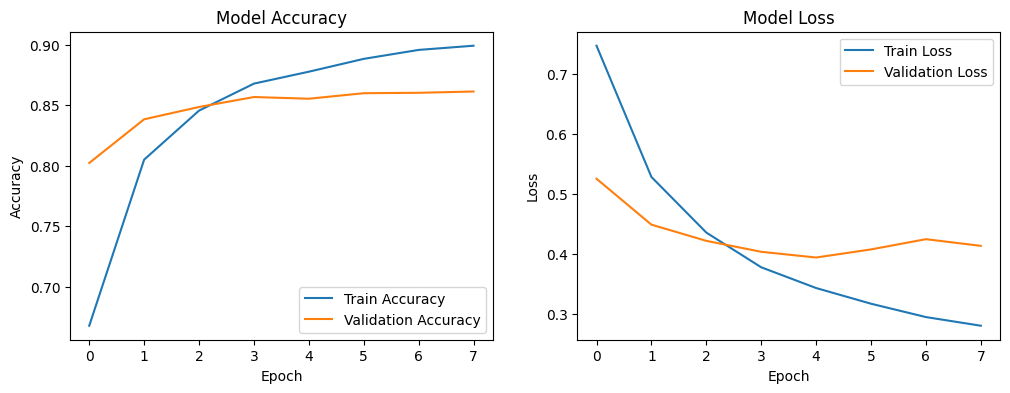

In [30]:
import matplotlib.pyplot as plt

# Grafik Akurasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [23]:
import numpy as np
def predict_sentiment(text):
    # 1. Bersihkan teks
    cleaned = clean_text(text)
    # 2. Ubah ke sequence
    seq = tokenizer.texts_to_sequences([cleaned])
    # 3. Padding
    padded = pad_sequences(seq, maxlen=100, padding='post')
    # 4. Prediksi
    prediction = model.predict(padded)
    labels = ['Negatif', 'Netral', 'Positif'] # Sesuaikan urutan dummy variabelmu

    result = labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    return result, confidence

# Tes Kalimat
test_ulasan = "Drivernya sopan banget, tapi aplikasinya agak berat pas mau pesan makanan"
label, skor = predict_sentiment(test_ulasan)
print(f"Hasil: {label} ({skor:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Hasil: Negatif (73.35%)
